In [21]:
import sys
import time
import os
import math
import random

####################################
#      Mersenne Twister 64-bit     #
# (ou placeholder com random abaixo)
####################################

NN = 312
mt = [0]*NN
mti = 0

def genrand64_int64():
    """
    Em C, haveria uma implementação real do Mersenne Twister 64 bits.
    Aqui, fazemos um placeholder usando random.getrandbits(64).
    Se quiser comportamento idêntico, implemente o MT64 completo.
    """
    return random.getrandbits(64)

def genrand64_real3():
    """
    Em C: ((genrand64_int64() >> 12) + 0.5)*(1.0/4503599627370496.0).
    Placeholder usando bits aleatórios em 64 bits:
    """
    return genrand64_int64() / float(1 << 64)

def init_genrand64(seed):
    global mt, mti
    mt[0] = seed
    for mti in range(1, NN):
        mt[mti] = (6364136223846793005 * (mt[mti - 1] ^ (mt[mti - 1] >> 62)) + mti) & ((1 << 64) - 1)

####################################
#            FUNÇÕES AUXILIARES
####################################

def find_node(i, j, bond):
    """
    int find_node (int i, int j, int **bond)
    Retorna o índice k se bond[i][k] == j, caso contrário -1
    """
    for k in range(1, bond[0][i] + 1):
        if bond[i][k] == j:
            return k
    return -1

def copy_network(N, origin_bond, copy_bond):
    """
    void copy_network (int N, int **origin_bond, int **copy_bond)
    Copia a estrutura bond de origin_bond para copy_bond.
    """
    for i in range(1, N+1):
        degree = origin_bond[0][i]
        copy_bond[0][i] = degree
        # Copia a lista de adjacências (0..degree)
        copy_bond[i] = origin_bond[i][:degree+1]

def generate_ERgraph(N, bond, E):
    """
    void generate_ERgraph (int N, int **bond, int E)
    Gera um grafo Erdős-Rényi com N nós e E arestas, populando bond.
    Não atualiza edges (se quiser edges, faça manualmente).
    """
    for i in range(1, N+1):
        bond[0][i] = 0

    for _ in range(E):
        n = int(genrand64_real3() * N) + 1
        m = int(genrand64_real3() * N)
        control = 0
        while control == 0:
            m += 1
            if m > N:
                m = 1
            if n != m and find_node(n, m, bond) < 0:
                control = 1
        bond[0][n] += 1
        bond[n].append(m)
        bond[0][m] += 1
        bond[m].append(n)

def clean_time_stamp(update_time, E):
    """
    void clean_time_stamp(unsigned long long *time_stamp, int E)
    Seta update_time[i] = 0, i=1..E.
    """
    for i in range(1, E+1):
        update_time[i] = 0

####################################
#    BFS E FUNÇÕES RELACIONADAS
####################################

def simple_bfs(C, N, bond, source, target, vec, tmp_vec, visited, reset, dag, nr_sp):
    """
    int simple_bfs(int C, int N, int **bond, int source, int target,
                   int *vec, int *tmp_vec, int *visited, int *reset,
                   int **dag, int *nr_sp)
    """
    int_distance = 0
    control = 0

    vec[0] = 1
    vec[1] = source
    visited[source] = 0
    dag[0][source] = 0
    nr_sp[source] = 1

    reset[0] = 1
    reset[1] = source

    while vec[0] > 0 and control == 0:
        tmp_vec[0] = 0
        int_distance += 1

        if int_distance == C:
            control = 1  # atingiu custo maximo

        for i in range(1, vec[0] + 1):
            n = vec[i]
            for j in range(1, bond[0][n] + 1):
                m = bond[n][j]

                if m == target:
                    control = 2  # achou alvo

                if visited[m] < 0:
                    tmp_vec[0] += 1
                    tmp_vec[tmp_vec[0]] = m
                    visited[m] = visited[n] + 1
                    reset[0] += 1
                    reset[reset[0]] = m

                if visited[m] == int_distance:
                    dag[0][m] += 1
                    dag[m][dag[0][m]] = n
                    nr_sp[m] += nr_sp[n]

        for i in range(tmp_vec[0] + 1):
            vec[i] = tmp_vec[i]

    return control

def sample_random_path(C, N, dag, source, target, path, nr_sp):
    """
    void sample_random_path(int C, int N, int **dag, int source, int target,
                            int *path, int *nr_sp)
    """
    control = 0
    path[0] = 1
    path[1] = target

    while control == 0:
        n = path[path[0]]
        if dag[0][n] > 0:
            T = 0
            for i in range(1, dag[0][n] + 1):
                T += nr_sp[dag[n][i]]

            q = int(genrand64_real3() * T) + 1
            if q > T:
                q = 1

            i = 0
            acc = 0
            found = 0

            while found == 0:
                i += 1
                acc += nr_sp[dag[n][i]]
                if q <= acc:
                    found = dag[n][i]

            path[0] += 1
            path[path[0]] = found

            if path[0] == C + 1 or path[path[0]] == source:
                control = 1
        else:
            path[0] = 0
            return

def get_path_of_pair(source, target, C, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp):
    """
    int get_path_of_pair(int source, int target, int C, int N, int **bond,
                         int *path, int *vec, int *tmp_vec, int *visited,
                         int *reset, int **dag, int *nr_sp)
    """
    control = simple_bfs(C, N, bond, source, target, vec, tmp_vec, visited, reset, dag, nr_sp)
    path[0] = 0
    if control == 2:
        sample_random_path(C, N, dag, source, target, path, nr_sp)

    # reset
    for i in range(1, reset[0] + 1):
        node = reset[i]
        visited[node] = -1
        dag[0][node] = 0
        nr_sp[node] = 0

    return path[0]

####################################
# GEOMETRIC DISTRIBUTION
####################################

def geometric_distribution(P):
    """
    unsigned long long geometric_distribution(double P)
    """
    if P <= 0:
        return -1
    if P == 1:
        return 1
    u = genrand64_real3()
    interval = int(1 + math.floor(math.log(u)/math.log(1. - P)))
    return interval

####################################
# AJUSTE DE PARES
####################################

def adjust_pair(pairs, q):
    """
    void adjust_pair(unsigned long **pairs, unsigned long q)
    """
    node1 = pairs[0][q]
    node2 = pairs[0][q]

    pairs[0][q] = pairs[0][pairs[0][0]]
    pairs[1][q] = pairs[1][pairs[0][0]]

    pairs[0][pairs[0][0]] = node1
    pairs[1][pairs[0][0]] = node2

    pairs[0][0] -= 1

####################################
# REMOCAO DE PARES
####################################

def remove_pair_w_pair_info_v2(C, N, bond, pairs, edges, update_time):
    """
    void remove_pair_w_pair_info_v2(int C, int N, int **bond,
                                    unsigned long **pairs,
                                    int **edges,
                                    unsigned long long *update_time)
    """
    path = [0]*(N+1)
    vec = [0]*(N+1)
    tmp_vec = [0]*(N+1)
    visited = [-1]*(N+1)
    reset = [0]*(N+1)
    nr_sp = [0]*(N+1)

    dag = []
    # dag[0] = [0]*(N+1); dag[i] = [0]*(bond[0][i]+1)
    for i in range(N+1):
        if i == 0:
            dag.append([0]*(N+1))
        else:
            dag.append([0]*(bond[0][i]+1))

    for i in range(1, N+1):
        visited[i] = -1
        dag[0][i] = 0
        nr_sp[i] = 0

    interval = 0
    E = edges[0][0]

    while pairs[0][0] > 0:
        num_pairs = pairs[0][0]
        link_prob = 2.0 * float(num_pairs)/(float(N)*float(N - 1))
        interval += geometric_distribution(link_prob)

        q = int(genrand64_real3()*num_pairs + 1)
        n = pairs[0][q]
        m = pairs[1][q]

        source = n
        target = m
        if bond[0][source] > bond[0][target]:
            n, m = m, n

        if C == -1:
            p = get_path_of_pair(n, m, N, N, bond, path, vec, tmp_vec,
                                 visited, reset, dag, nr_sp)
        else:
            p = get_path_of_pair(n, m, C, N, bond, path, vec, tmp_vec,
                                 visited, reset, dag, nr_sp)

        if p > 0:
            for j in range(1, path[0]):
                s = path[j]
                t = path[j + 1]

                v = find_node(s, t, bond)
                bond[s][v] = bond[s][bond[0][s]]
                bond[0][s] -= 1

                v = find_node(t, s, bond)
                bond[t][v] = bond[t][bond[0][t]]
                bond[0][t] -= 1

                E += 1
                if s < t:
                    edges[0][E] = s
                    edges[1][E] = t
                else:
                    edges[0][E] = t
                    edges[1][E] = s
                update_time[E] += interval

            control = simple_bfs(C, N, bond, n, m, vec, tmp_vec,
                                 visited, reset, dag, nr_sp)
            if control == 1:
                adjust_pair(pairs, q)
        else:
            adjust_pair(pairs, q)

        for i in range(1, reset[0] + 1):
            node = reset[i]
            visited[node] = -1
            dag[0][node] = 0
            nr_sp[node] = 0

    edges[0][0] = E

def remove_pair_wo_pair_info_v2(C, N, bond, edges, E, update_time, threshold):
    """
    void remove_pair_wo_pair_info_v2(int C, int N, int **bond,
                                     int **edges, int E,
                                     unsigned long long *update_time,
                                     int threshold)
    """
    path = [0]*(N+1)
    vec = [0]*(N+1)
    tmp_vec = [0]*(N+1)
    visited = [-1]*(N+1)
    reset = [0]*(N+1)
    nr_sp = [0]*(N+1)

    dag = []
    dag.append([0]*(N+1))
    for i in range(1, N+1):
        dag.append([0]*(bond[0][i]+1))
        visited[i] = -1
        dag[0][i] = 0
        nr_sp[i] = 0

    count_E = 0
    tau = 1
    num_failures = 0

    while num_failures < threshold:
        while True:
            n = int(genrand64_real3()*N) + 1
            m = int(genrand64_real3()*N) + 1
            if n != m:
                break

        source = n
        target = m
        if bond[0][source] > bond[0][target]:
            n, m = m, n

        if C == -1:
            p = get_path_of_pair(n, m, N, N, bond, path, vec, tmp_vec,
                                 visited, reset, dag, nr_sp)
        else:
            p = get_path_of_pair(n, m, C, N, bond, path, vec, tmp_vec,
                                 visited, reset, dag, nr_sp)

        if p > 0:
            num_failures = 0
            for j in range(1, path[0]):
                s = path[j]
                t = path[j + 1]

                v1 = find_node(s, t, bond)
                bond[s][v1] = bond[s][bond[0][s]]
                bond[0][s] -= 1

                v2 = find_node(t, s, bond)
                bond[t][v2] = bond[t][bond[0][t]]
                bond[0][t] -= 1

                count_E += 1
                if s < t:
                    edges[0][count_E] = s
                    edges[1][count_E] = t
                else:
                    edges[0][count_E] = t
                    edges[1][count_E] = s
                update_time[count_E] += tau
        else:
            num_failures += 1

        tau += 1

    # Ajusta update_time das arestas não removidas
    for i in range(count_E + 1, E + 1):
        update_time[i] += tau

    edges[0][0] = count_E

####################################
#  FUNÇÃO find_all_possible_pairs
####################################

def find_all_possible_pairs(C, N, bond, pairs):
    """
    int find_all_possible_pairs(int C, int N, int **bond, unsigned long **pairs)
    """
    num_pairs = 0
    dag = []
    list_pairs = []

    vec = [0]*(N+1)
    tmp_vec = [0]*(N+1)
    visited = [-1]*(N+1)
    reset = [0]*(N+1)
    nr_sp = [0]*(N+1)

    dag.append([0]*(N+1))
    for i in range(1, N+1):
        dag.append([0]*(bond[0][i]+1))

    list_pairs.append([0]*(N+1))
    for i in range(1, N+1):
        list_pairs.append([])
        list_pairs[i].append(0)

    for i in range(1, N+1):
        visited[i] = -1
        dag[0][i] = 0
        nr_sp[i] = 0

    target = -1

    for source in range(1, N+1):
        control = simple_bfs(C, N, bond, source, target,
                             vec, tmp_vec, visited, reset, dag, nr_sp)

        for k in range(1, reset[0] + 1):
            n = reset[k]
            if source < n and find_node(source, n, list_pairs) < 0:
                list_pairs[0][source] += 1
                list_pairs[source].append(n)
                num_pairs += 1

        for k in range(1, reset[0] + 1):
            node = reset[k]
            visited[node] = -1
            dag[0][node] = 0
            nr_sp[node] = 0

    # Expande pairs se necessário
    while len(pairs[0]) < num_pairs + 1:
        pairs[0].append(0)
    while len(pairs[1]) < num_pairs + 1:
        pairs[1].append(0)

    num_pairs = 0
    for i in range(1, N+1):
        for j in range(1, list_pairs[0][i] + 1):
            num_pairs += 1
            pairs[0][num_pairs] = i
            pairs[1][num_pairs] = list_pairs[i][j]

    pairs[0][0] = num_pairs

    return num_pairs

####################################
#         FUNÇÕES DE ÁRVORE
####################################

def tree_find_root(n, root, res):
    """
    void tree_find_root (int n, int **root, int *res)
    """
    if root[0][n] == n:
        res[0] = root[0][n]
        res[1] = root[1][n]
        return
    tree_find_root(root[0][n], root, res)

####################################
#   modified_NZ_algorithm
####################################

def modified_NZ_algorithm(N, edges, largest_cluster):
    """
    void modified_NZ_algorithm (int N, int **edges, double **largest_cluster)
    """
    root = [ [0]*(N+1), [0]*(N+1) ]
    res = [0, 0]

    larg = 1
    av2 = float(N - 1)

    # inicializa root
    for i in range(1, N+1):
        root[0][i] = i
        root[1][i] = 1

    E = edges[0][0]
    for e in range(E, 0, -1):
        n = edges[0][e]
        m = edges[1][e]

        # av2 += larg^2
        av2 += float(larg)*float(larg)

        # acha raiz n e m
        tree_find_root(n, root, res)
        rn, sn = res[0], res[1]

        tree_find_root(m, root, res)
        rm, sm = res[0], res[1]

        if rn != rm:
            av2 -= float(sn)*float(sn)
            av2 -= float(sm)*float(sm)

            if sn > sm:
                root[0][rm] = rn
                root[1][rm] = 1
                root[1][rn] = sn + sm
            else:
                root[0][rn] = rm
                root[1][rn] = 1
                root[1][rm] = sn + sm

            if sn + sm > larg:
                larg = sn + sm

        tmp = float(larg)/float(N)
        largest_cluster[1][e] = tmp
        largest_cluster[2][e] = tmp*tmp
        largest_cluster[3][e] = tmp*tmp*tmp
        largest_cluster[4][e] = tmp*tmp*tmp*tmp

        av = float(N) - float(larg)
        if rn != rm:
            av2 += float(sn+sm)*float(sn+sm)
        av2 -= float(larg)*float(larg)
        if av > 0:
            largest_cluster[5][e] = av2/av

####################################
# efficient_pair_removal
####################################

def efficient_pair_removal(C, N, bond, edges, E, update_time, threshold):
    """
    void efficient_pair_removal(int C, int N, int **bond, int **edges, int E,
                                unsigned long long *update_time, int threshold)
    {
        remove_pair_wo_pair_info_v2(...)
        pairs = ...
        find_all_possible_pairs(...)
        remove_pair_w_pair_info_v2(...)
    }
    """
    # Fase 1
    remove_pair_wo_pair_info_v2(C, N, bond, edges, E, update_time, threshold)

    # Fase 2 (a)
    # Em C, pairs é (unsigned long **)malloc, etc.
    # Em Python, definimos um array [[], []].
    pairs = [ [0], [0] ]
    num_pairs = find_all_possible_pairs(C, N, bond, pairs)
    remove_pair_w_pair_info_v2(C, N, bond, pairs, edges, update_time)
    # free() em Python não é necessário

####################################
# main
####################################

def main(argc, argv):
    start = time.time()
    mean_cpu_time = 0.0

    # Se estiver em Jupyter/VSCode e argv tiver argumentos estranhos,
    # podemos usar defaults se argc < 6:
    if argc < 6:
        print("Argumentos insuficientes! Usando valores-padrão:")
        N = 4096
        avg_k = 4
        C = N
        num_iter = 10
        num_instance = 1
    else:
        N = int(argv[1])       # ex: size of network
        avg_k = int(argv[2])   # ex: mean degree
        C = int(argv[3])       # ex: maximum cost
        num_iter = int(argv[4])
        num_instance = int(argv[5])

    E = int(0.5*N*avg_k)

    # Aloca as estruturas
    bond = [[] for _ in range(N+1)]
    bond[0] = [0]*(N+1)
    for i in range(1, N+1):
        bond[i] = [0]

    copy_bond = [[] for _ in range(N+1)]
    copy_bond[0] = [0]*(N+1)

    edges = [[] for _ in range(2)]
    edges[0] = [0]*(E+1)
    edges[1] = [0]*(E+1)

    update_time = [0]*(E+1)

    largest_cluster = []
    for _ in range(6):
        largest_cluster.append([0.0]*(E+1))

    # Semente para o gerador
    pid_id = int(time.time()) * os.getpid()
    init_genrand64(pid_id)

    for x in range(num_instance):
        generate_ERgraph(N, bond, E)

        for i in range(num_iter):
            copy_network(N, bond, copy_bond)
            clean_time_stamp(update_time, E)

            # threshold = 7*N^0.44
            threshold = int(7*(N**0.44))

            # Chama efficient_pair_removal
            efficient_pair_removal(C, N, copy_bond, edges, E, update_time, threshold)

            # Roda modified_NZ_algorithm
            modified_NZ_algorithm(N, edges, largest_cluster)

            # Gera dir e nome de arquivo
            if C > 0:
                dir_path = f"./data/N{N}/k{avg_k}/C{C}/"
                file_id = i  # se quiser 1 CSV por iteração
                file_name = f"{dir_path}full_data_{file_id}.csv"
            else:
                dir_path = f"./data/N{N}/k{avg_k}/C{N}/"
                file_id = i
                file_name = f"{dir_path}full_data_{file_id}.csv"

            os.makedirs(dir_path, exist_ok=True)

            # Verificar se edges[0][0] > 0
            # Se for 0, o CSV sairá vazio
            with open(file_name, "w") as f:
                for j in range(1, edges[0][0] + 1):
                    removed_edges = float(j)/float(edges[0][0])
                    f.write(f"{removed_edges:.10f} "
                            f"{largest_cluster[1][j]:.10f} "
                            f"{largest_cluster[2][j]:.10f} "
                            f"{largest_cluster[3][j]:.10f} "
                            f"{largest_cluster[4][j]:.10f} "
                            f"{largest_cluster[5][j]:.10f} "
                            f"{edges[0][j]} "
                            f"{edges[1][j]} "
                            f"{update_time[j]}\n")

    end = time.time()
    cpu_time_used = (end - start)
    print(f"# mean simulation time for N={N} C={C} calculated from {num_instance} instances "
          f"and {num_iter} iterations : {cpu_time_used/(num_instance*num_iter)}")

if __name__ == "__main__":
    main(len(sys.argv), sys.argv)


Argumentos insuficientes! Usando valores-padrão:
# mean simulation time for N=4096 C=4096 calculated from 1 instances and 10 iterations : 1.4562090635299683


# Validation

In [22]:
import pandas as pd
import os
import pandas as pd
import matplotlib.pyplot as plt


def load_raw_data(N, avg_k, C, drop_node=True):
    data_dir = f'./data/N{N}/k{avg_k}/C{C}/'
    dfs = []

    for file_name in os.listdir(data_dir):
        df = pd.read_csv(os.path.join(data_dir, file_name), 
                        sep=' ', 
                        names=["p", "m1", "m2", "m3", "m4", "s", "node1", "node2", "t"],
                        )
        if drop_node==True:
            df.drop(['node1', 'node2'], axis=1, inplace=True)
        dfs.append(df)
    
    return dfs

def get_averaged_curve(N, avg_k, C):
    dfs = load_raw_data(N, avg_k, C)
    combined_df = pd.concat(dfs)
    mean_df = combined_df.groupby('p').mean()
    std_df = combined_df.groupby('p').std()

    final_df = mean_df.merge(std_df, on='p', suffixes=('', '_std'))
    final_df = final_df.reset_index()
    
    return final_df

In [ ]:
N = 2048
avg_k = 4
C = N


dfs = load_raw_data(N=N, avg_k=avg_k, C=C)
final_df = get_averaged_curve(N=N, avg_k=avg_k, C=C)
final_df

,p,m1,m2,m3,m4,s,t,m1_std,m2_std,m3_std,m4_std,s_std,t_std
0,0.000244,0.980957,9.622767e-01,9.439521e-01,0.925976,1.153846,1.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00
1,0.000488,0.980957,9.622767e-01,9.439521e-01,0.925976,1.153846,1.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00
2,0.000732,0.980957,9.622767e-01,9.439521e-01,0.925976,1.153846,1.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00
3,0.000977,0.980957,9.622767e-01,9.439521e-01,0.925976,1.153846,1.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00
4,0.001221,0.980957,9.622767e-01,9.439521e-01,0.925976,1.153846,1.1,0.0,0.0,0.0,0.0,0.0,3.162278e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4091,0.999023,0.000977,9.537000e-07,9.000000e-10,0.000000,1.003910,9857262.8,0.0,0.0,0.0,0.0,0.0,1.403740e+06
4092,0.999268,0.000977,9.537000e-07,9.000000e-10,0.000000,1.002933,10724106.2,0.0,0.0,0.0,0.0,0.0,1.687497e+06
4093,0.999512,0.000977,9.537000e-07,9.000000e-10,0.000000,1.001955,11246375.5,0.0,0.0,0.0,0.0,0.0,2.032953e+06
4094,0.999756,0.000977,9.537000e-07,9.000000e-10,0.000000,1.000978,12025221.8,0.0,0.0,0.0,0.0,0.0,1.729491e+06


# My simulations

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


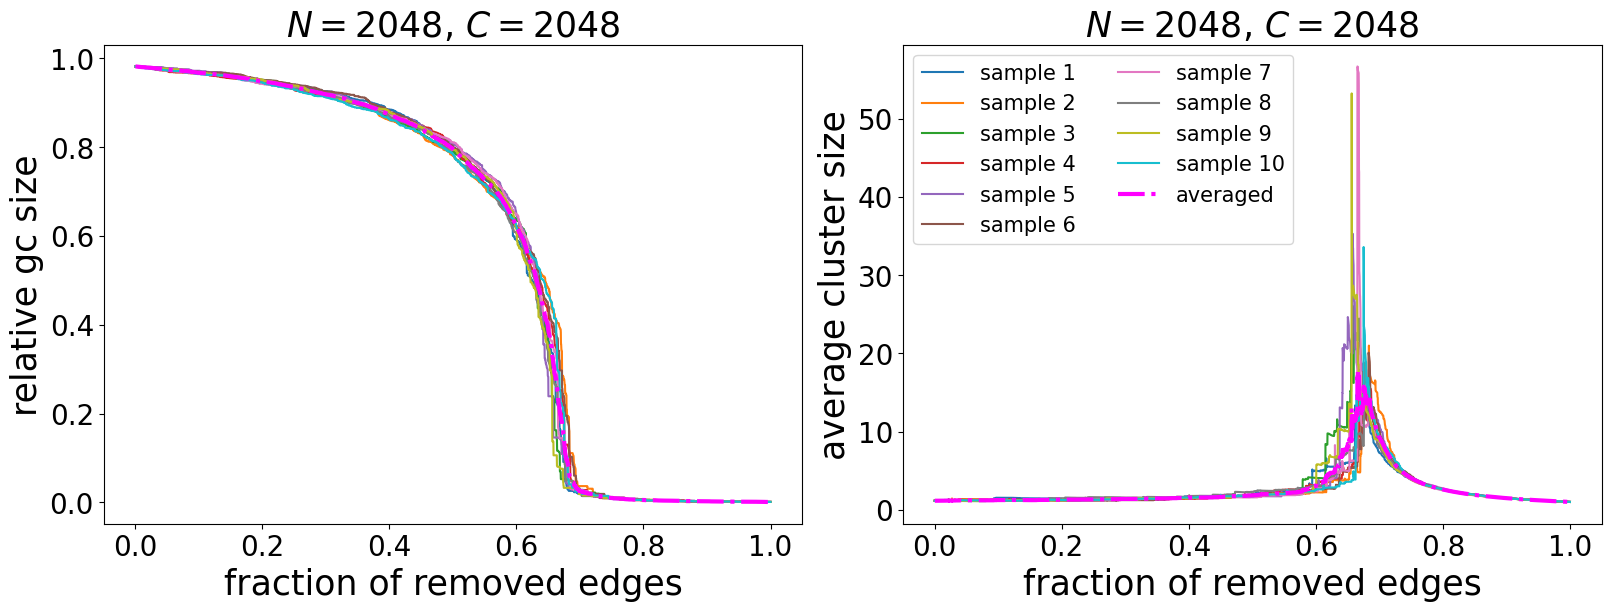

In [4]:
fig, ax = plt.subplots(ncols=2, figsize=(16, 6), constrained_layout=True)

for i, df in enumerate(dfs):
    ax[0].plot(df["p"], df["m1"], label=f'sample {i+1}')
    ax[1].plot(df["p"], df["s"], label=f'sample {i+1}')

ax[0].plot(final_df["p"], final_df["m1"], ls='-.', c='magenta', lw=3, label='averaged')
ax[1].plot(final_df["p"], final_df["s"], ls='-.', c='magenta', lw=3, label='averaged')

ax[0].set_title(f'${N = }$, ${C = }$', fontsize=25)
ax[0].set_xlabel('fraction of removed edges', fontsize=25)
ax[0].set_ylabel('relative gc size', fontsize=25)
ax[0].tick_params('both', labelsize=20)

ax[1].set_title(f'${N = }$, ${C = }$', fontsize=25)
ax[1].set_xlabel('fraction of removed edges', fontsize=25)
ax[1].set_ylabel('average cluster size', fontsize=25)
ax[1].tick_params('both', labelsize=20)
ax[1].legend(fontsize=15, ncol=2)

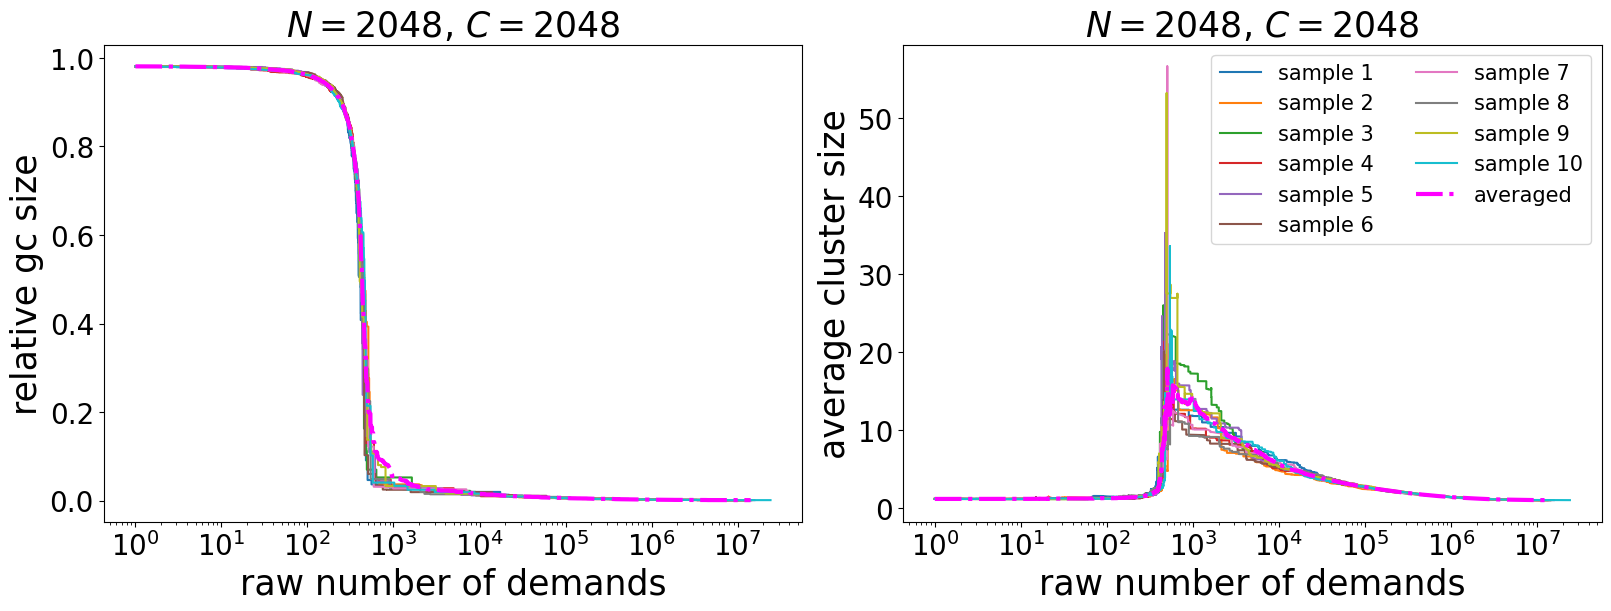

In [5]:
fig, ax = plt.subplots(ncols=2, figsize=(16, 6), constrained_layout=True)

for i, df in enumerate(dfs):
    ax[0].plot(df["t"], df["m1"], label=f'sample {i+1}')
    ax[1].plot(df["t"], df["s"], label=f'sample {i+1}')

ax[0].plot(final_df["t"], final_df["m1"], ls='-.', c='magenta', lw=3, label='averaged')
ax[1].plot(final_df["t"], final_df["s"], ls='-.', c='magenta', lw=3, label='averaged')

ax[0].set_title(f'${N = }$, ${C = }$', fontsize=25)
ax[0].set_xlabel('raw number of demands', fontsize=25)
ax[0].set_ylabel('relative gc size', fontsize=25)
ax[0].tick_params('both', labelsize=20)
ax[0].set_xscale('log')

ax[1].set_title(f'${N = }$, ${C = }$', fontsize=25)
ax[1].set_xlabel('raw number of demands', fontsize=25)
ax[1].set_ylabel('average cluster size', fontsize=25)
ax[1].tick_params('both', labelsize=20)
ax[1].legend(fontsize=15, ncol=2)
ax[1].set_xscale('log')

plt.show()

In [23]:
C1_dfs = [get_averaged_curve(N=N, avg_k=avg_k, C=1) for N in [1024, 2048, 4096]]
C2_dfs = [get_averaged_curve(N=N, avg_k=avg_k, C=2) for N in [1024, 2048, 4096]]
C3_dfs = [get_averaged_curve(N=N, avg_k=avg_k, C=3) for N in [1024, 2048, 4096]]
CN_dfs = [get_averaged_curve(N=N, avg_k=avg_k, C=N) for N in [1024, 2048, 4096]]

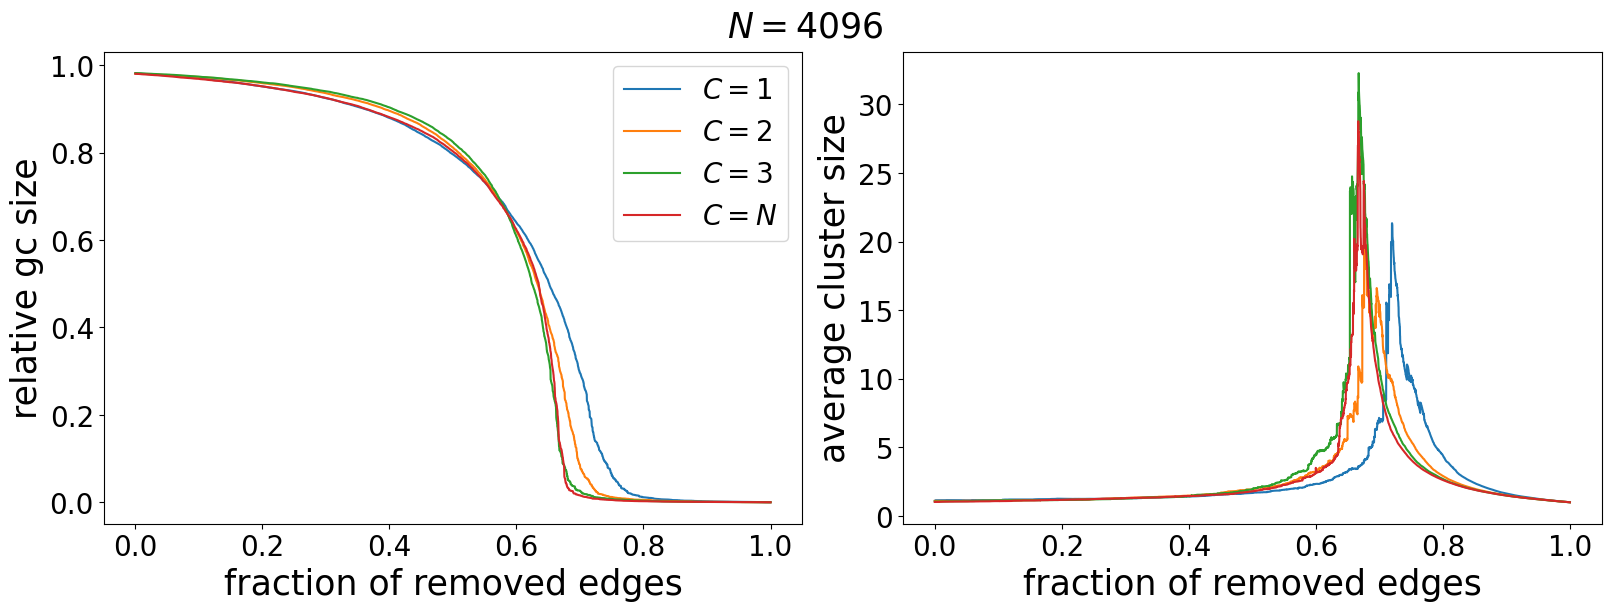

In [24]:
fig, ax = plt.subplots(ncols=2, figsize=(16, 6), constrained_layout=True)

fig.suptitle(f'$N=4096$', fontsize=25)

ax[0].plot(C1_dfs[-1]["p"], C1_dfs[-1]["m1"], label='$C=1$')
ax[0].plot(C2_dfs[-1]["p"], C2_dfs[-1]["m1"], label='$C=2$')
ax[0].plot(C3_dfs[-1]["p"], C3_dfs[-1]["m1"], label='$C=3$')
ax[0].plot(CN_dfs[-1]["p"], CN_dfs[-1]["m1"], label='$C=N$')

ax[0].set_xlabel("fraction of removed edges", fontsize=25)
ax[0].set_ylabel("relative gc size", fontsize=25)
ax[0].tick_params("both", labelsize=20)
ax[0].legend(fontsize=20)


ax[1].plot(C1_dfs[-1]["p"], C1_dfs[-1]["s"], label='$C=1$')
ax[1].plot(C2_dfs[-1]["p"], C2_dfs[-1]["s"], label='$C=2$')
ax[1].plot(C3_dfs[-1]["p"], C3_dfs[-1]["s"], label='$C=3$')
ax[1].plot(CN_dfs[-1]["p"], CN_dfs[-1]["s"], label='$C=N$')

ax[1].set_xlabel("fraction of removed edges", fontsize=25)
ax[1].set_ylabel("average cluster size", fontsize=25)
ax[1].tick_params("both", labelsize=20)

plt.show()

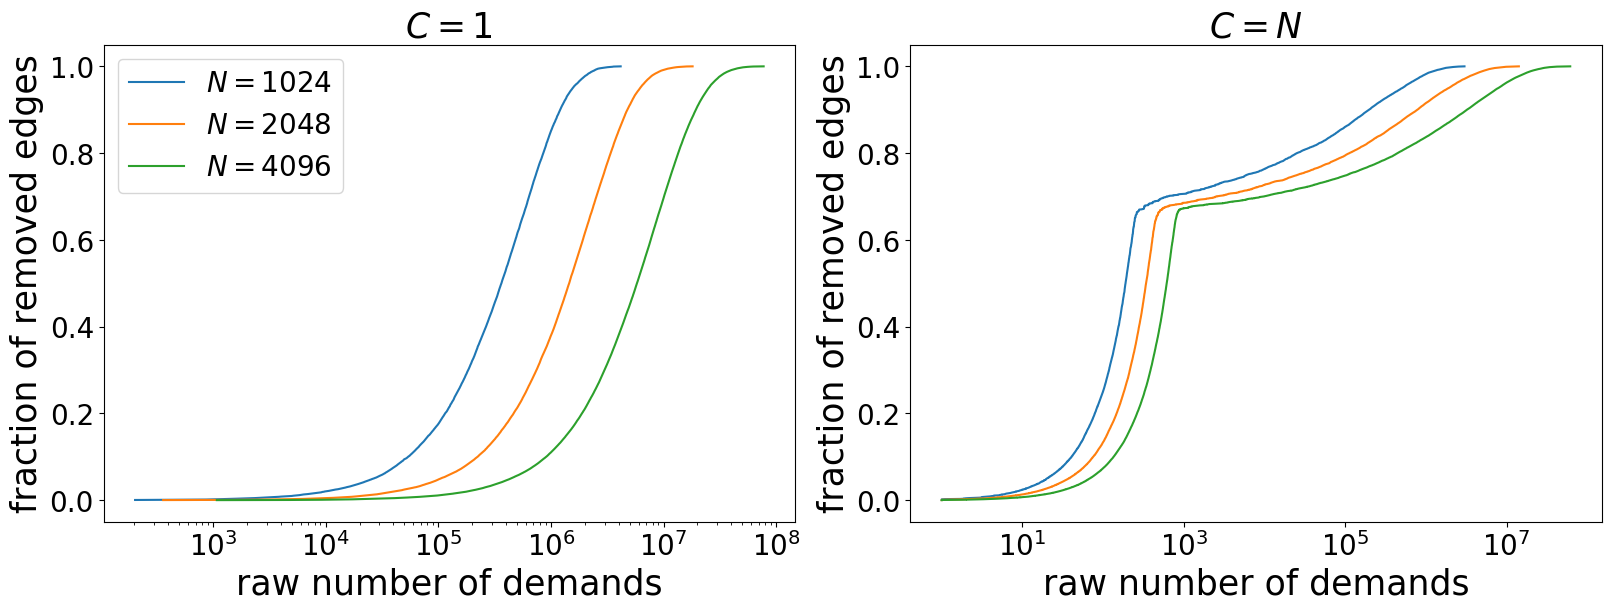

In [25]:
fig, ax = plt.subplots(ncols=2, figsize=(16, 6), constrained_layout=True)

ax[0].plot(C1_dfs[0]["t"], C1_dfs[0]["p"], label='$N=1024$')
ax[0].plot(C1_dfs[1]["t"], C1_dfs[1]["p"], label='$N=2048$')
ax[0].plot(C1_dfs[2]["t"], C1_dfs[2]["p"], label='$N=4096$')

ax[0].set_title('$C=1$', fontsize=25)
ax[0].set_xlabel("raw number of demands", fontsize=25)
ax[0].set_ylabel("fraction of removed edges", fontsize=25)
ax[0].tick_params("both", labelsize=20)
ax[0].set_xscale('log')
ax[0].legend(fontsize=20)


ax[1].plot(CN_dfs[0]["t"], CN_dfs[0]["p"], label='$N=1024$')
ax[1].plot(CN_dfs[1]["t"], CN_dfs[1]["p"], label='$N=2048$')
ax[1].plot(CN_dfs[2]["t"], CN_dfs[2]["p"], label='$N=4006$')

ax[1].set_title('$C=N$', fontsize=25)
ax[1].set_xlabel("raw number of demands", fontsize=25)
ax[1].set_ylabel("fraction of removed edges", fontsize=25)
ax[1].tick_params("both", labelsize=20)
ax[1].set_xscale('log')

plt.show()

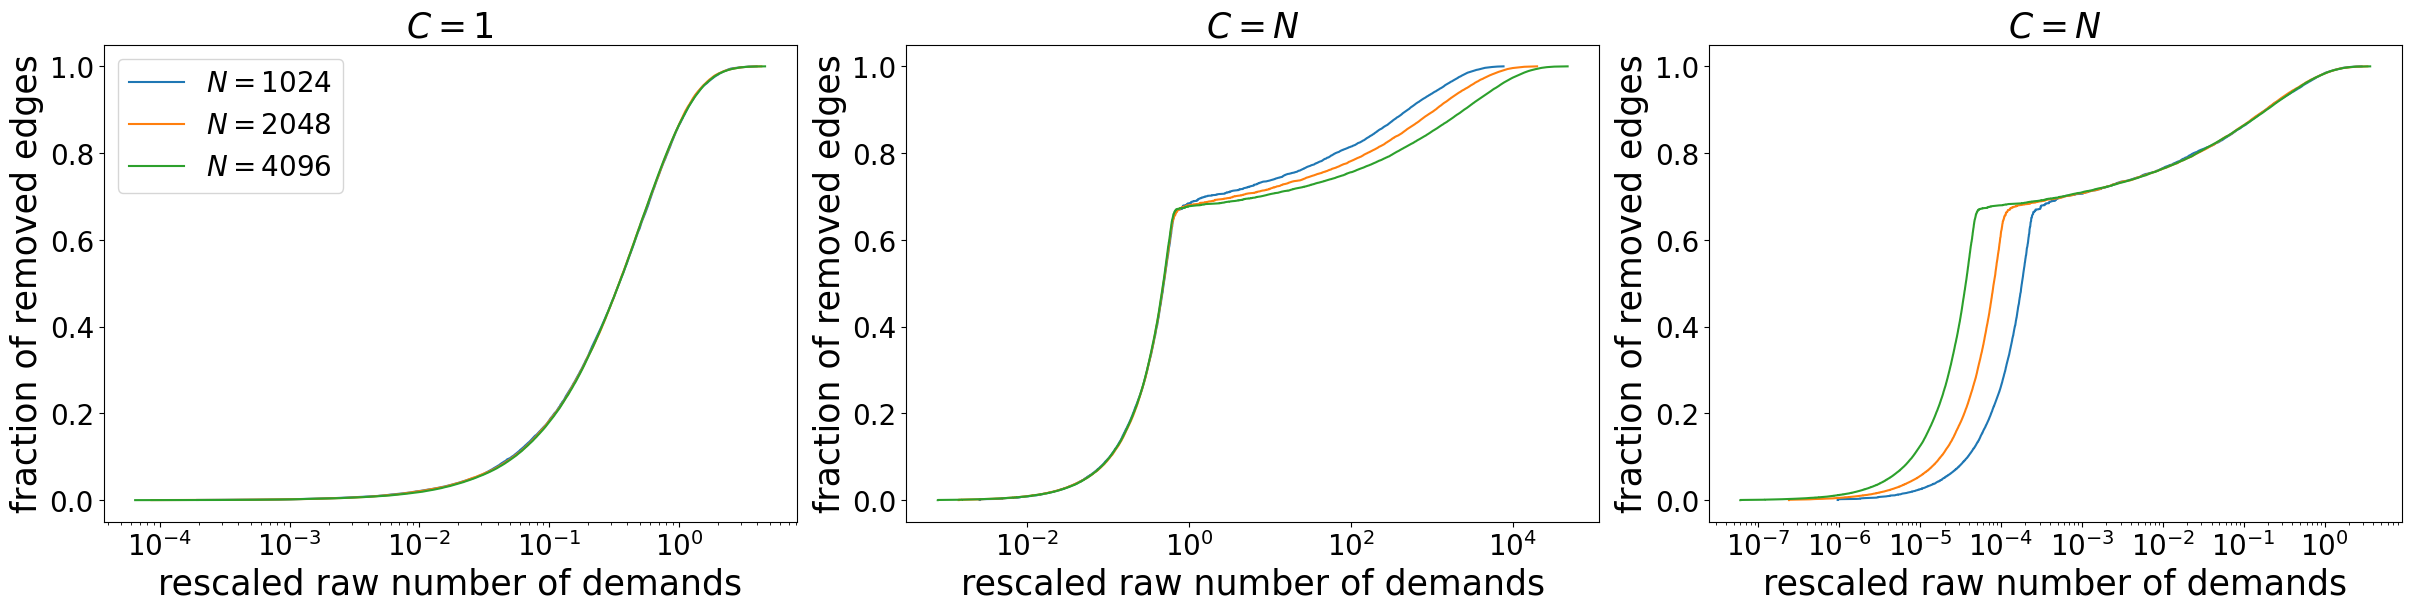

In [28]:
import numpy as np
fig, ax = plt.subplots(ncols=3, figsize=(24, 6), constrained_layout=True)

ax[0].plot(C1_dfs[0]["t"] * np.power(1024, -2.), C1_dfs[0]["p"], label='$N=1024$')
ax[0].plot(C1_dfs[1]["t"] * np.power(2048, -2.), C1_dfs[1]["p"], label='$N=2048$')
ax[0].plot(C1_dfs[2]["t"] * np.power(4096, -2.), C1_dfs[2]["p"], label='$N=4096$')

ax[0].set_title('$C=1$', fontsize=25)
ax[0].set_xlabel("rescaled raw number of demands", fontsize=25)
ax[0].set_ylabel("fraction of removed edges", fontsize=25)
ax[0].tick_params("both", labelsize=20)
ax[0].set_xscale('log')
ax[0].legend(fontsize=20)


ax[1].plot(CN_dfs[0]["t"] * np.power(1024, -0.86), CN_dfs[0]["p"], label='$N=1024$')
ax[1].plot(CN_dfs[1]["t"] * np.power(2048, -0.86), CN_dfs[1]["p"], label='$N=2048$')
ax[1].plot(CN_dfs[2]["t"] * np.power(4096, -0.86), CN_dfs[2]["p"], label='$N=4096$')

ax[1].set_title('$C=N$', fontsize=25)
ax[1].set_xlabel("rescaled raw number of demands", fontsize=25)
ax[1].set_ylabel("fraction of removed edges", fontsize=25)
ax[1].tick_params("both", labelsize=20)
ax[1].set_xscale('log')

ax[2].plot(CN_dfs[0]["t"] * np.power(1024, -2.), CN_dfs[0]["p"], label='$N=1024$')
ax[2].plot(CN_dfs[1]["t"] * np.power(2048, -2.), CN_dfs[1]["p"], label='$N=2048$')
ax[2].plot(CN_dfs[2]["t"] * np.power(4096, -2.), CN_dfs[2]["p"], label='$N=4096$')

ax[2].set_title('$C=N$', fontsize=25)
ax[2].set_xlabel("rescaled raw number of demands", fontsize=25)
ax[2].set_ylabel("fraction of removed edges", fontsize=25)
ax[2].tick_params("both", labelsize=20)
ax[2].set_xscale('log')

plt.show()

----------------

# Simulation Artigo

In [6]:
import pandas as pd
import os
import pandas as pd
import matplotlib.pyplot as plt


def load_raw_data(N, avg_k, C, drop_node=True):
    data_dir = f'C:/Users/victo/OneDrive/Área de Trabalho/shortest_path_percolation/shortest-path-percolation/data/N{N}/k{avg_k}/C{C}/'
    dfs = []

    for file_name in os.listdir(data_dir):
        df = pd.read_csv(os.path.join(data_dir, file_name), 
                        sep=' ', 
                        names=["p", "m1", "m2", "m3", "m4", "s", "node1", "node2", "t"],
                        )
        if drop_node==True:
            df.drop(['node1', 'node2'], axis=1, inplace=True)
        dfs.append(df)
    
    return dfs

def get_averaged_curve(N, avg_k, C):
    dfs = load_raw_data(N, avg_k, C)
    combined_df = pd.concat(dfs)
    mean_df = combined_df.groupby('p').mean()
    std_df = combined_df.groupby('p').std()

    final_df = mean_df.merge(std_df, on='p', suffixes=('', '_std'))
    final_df = final_df.reset_index()
    
    return final_df

In [7]:
N = 2048
avg_k = 4
C = 2048


dfs = load_raw_data(N=N, avg_k=avg_k, C=C)
final_df = get_averaged_curve(N=N, avg_k=avg_k, C=C)
final_df

,p,m1,m2,m3,m4,s,t,m1_std,m2_std,m3_std,m4_std,s_std,t_std
0,0.000244,0.981152,9.626671e-01,9.445373e-01,0.926756,1.052749,1.0,0.002830,0.005556,0.008180,0.010706,0.030877,0.000000e+00
1,0.000488,0.981152,9.626671e-01,9.445373e-01,0.926756,1.052749,1.0,0.002830,0.005556,0.008180,0.010706,0.030877,0.000000e+00
2,0.000732,0.981104,9.625716e-01,9.443971e-01,0.926573,1.052749,1.0,0.002885,0.005662,0.008336,0.010909,0.030877,0.000000e+00
3,0.000977,0.981104,9.625716e-01,9.443971e-01,0.926573,1.052749,1.1,0.002885,0.005662,0.008336,0.010909,0.030877,3.162278e-01
4,0.001221,0.981006,9.623800e-01,9.441152e-01,0.926204,1.057485,1.4,0.002888,0.005670,0.008347,0.010924,0.034300,5.163978e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4091,0.999023,0.000977,9.537000e-07,9.000000e-10,0.000000,1.003910,9351809.3,0.000000,0.000000,0.000000,0.000000,0.000000,1.081059e+06
4092,0.999268,0.000977,9.537000e-07,9.000000e-10,0.000000,1.002933,9837798.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.285499e+06
4093,0.999512,0.000977,9.537000e-07,9.000000e-10,0.000000,1.001955,10257242.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.176950e+06
4094,0.999756,0.000977,9.537000e-07,9.000000e-10,0.000000,1.000978,11086891.7,0.000000,0.000000,0.000000,0.000000,0.000000,1.443376e+06


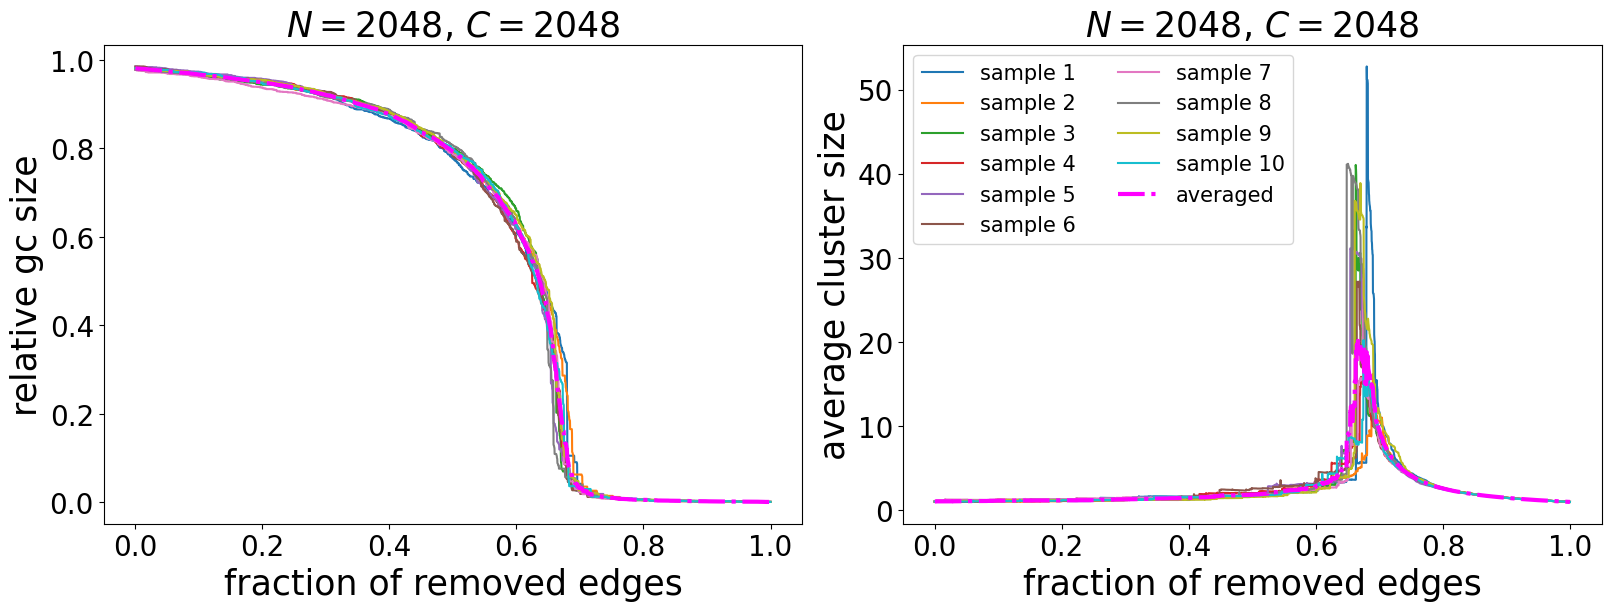

In [8]:
fig, ax = plt.subplots(ncols=2, figsize=(16, 6), constrained_layout=True)

for i, df in enumerate(dfs):
    ax[0].plot(df["p"], df["m1"], label=f'sample {i+1}')
    ax[1].plot(df["p"], df["s"], label=f'sample {i+1}')

ax[0].plot(final_df["p"], final_df["m1"], ls='-.', c='magenta', lw=3, label='averaged')
ax[1].plot(final_df["p"], final_df["s"], ls='-.', c='magenta', lw=3, label='averaged')

ax[0].set_title(f'${N = }$, ${C = }$', fontsize=25)
ax[0].set_xlabel('fraction of removed edges', fontsize=25)
ax[0].set_ylabel('relative gc size', fontsize=25)
ax[0].tick_params('both', labelsize=20)

ax[1].set_title(f'${N = }$, ${C = }$', fontsize=25)
ax[1].set_xlabel('fraction of removed edges', fontsize=25)
ax[1].set_ylabel('average cluster size', fontsize=25)
ax[1].tick_params('both', labelsize=20)
ax[1].legend(fontsize=15, ncol=2)

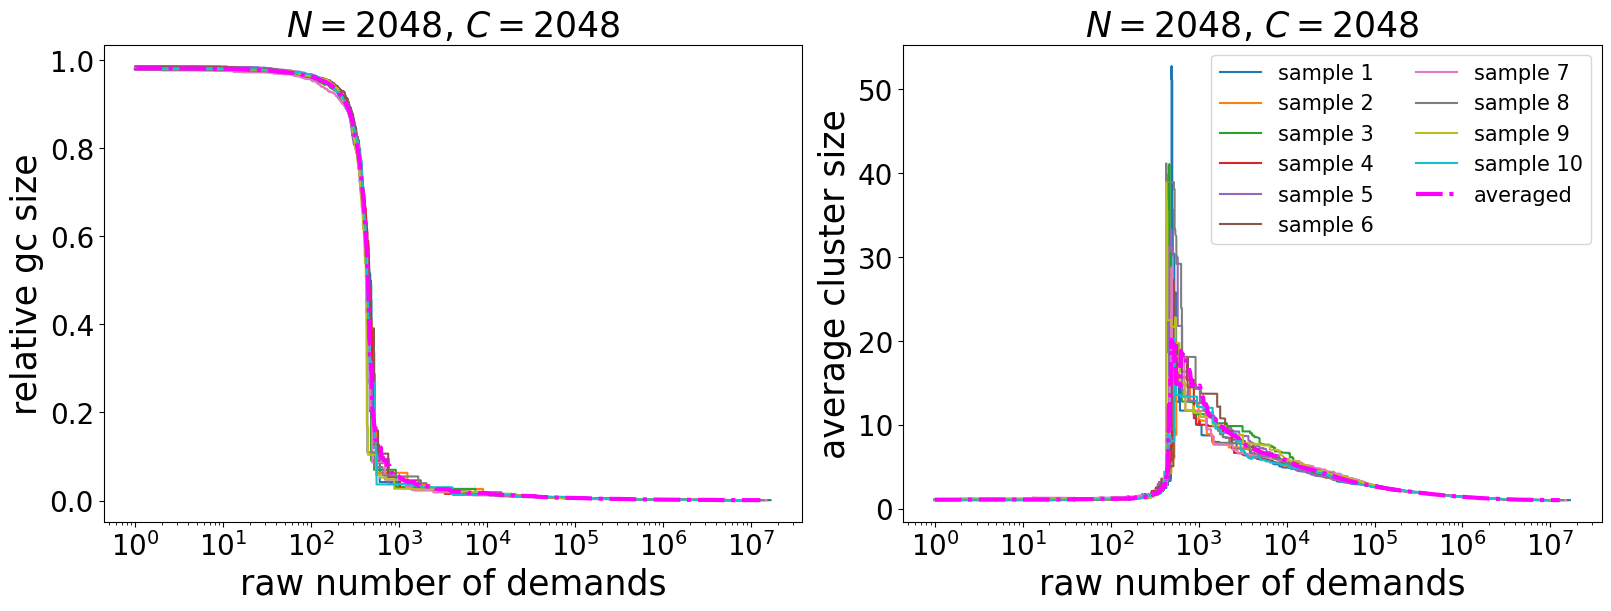

In [9]:
fig, ax = plt.subplots(ncols=2, figsize=(16, 6), constrained_layout=True)

for i, df in enumerate(dfs):
    ax[0].plot(df["t"], df["m1"], label=f'sample {i+1}')
    ax[1].plot(df["t"], df["s"], label=f'sample {i+1}')

ax[0].plot(final_df["t"], final_df["m1"], ls='-.', c='magenta', lw=3, label='averaged')
ax[1].plot(final_df["t"], final_df["s"], ls='-.', c='magenta', lw=3, label='averaged')

ax[0].set_title(f'${N = }$, ${C = }$', fontsize=25)
ax[0].set_xlabel('raw number of demands', fontsize=25)
ax[0].set_ylabel('relative gc size', fontsize=25)
ax[0].tick_params('both', labelsize=20)
ax[0].set_xscale('log')

ax[1].set_title(f'${N = }$, ${C = }$', fontsize=25)
ax[1].set_xlabel('raw number of demands', fontsize=25)
ax[1].set_ylabel('average cluster size', fontsize=25)
ax[1].tick_params('both', labelsize=20)
ax[1].legend(fontsize=15, ncol=2)
ax[1].set_xscale('log')

plt.show()